# Yahtzee Simulation
Monte Carlo simulation of Yahtzee with multiple strategies. Each strategy plays thousands of full games; we compare average scores and score distributions.

In [1]:
import random
from collections import Counter
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt

## Scoring Logic
All 13 Yahtzee categories plus bonus detection.

In [2]:
CATEGORIES = [
    "ones", "twos", "threes", "fours", "fives", "sixes",
    "three_of_a_kind", "four_of_a_kind", "full_house",
    "small_straight", "large_straight", "yahtzee", "chance"
]

def score_dice(dice, category):
    """Return the score for a given dice roll in a given category."""
    counts = Counter(dice)
    face_counts = sorted(counts.values(), reverse=True)

    if category == "ones":   return sum(d for d in dice if d == 1)
    if category == "twos":   return sum(d for d in dice if d == 2)
    if category == "threes": return sum(d for d in dice if d == 3)
    if category == "fours":  return sum(d for d in dice if d == 4)
    if category == "fives":  return sum(d for d in dice if d == 5)
    if category == "sixes":  return sum(d for d in dice if d == 6)

    if category == "three_of_a_kind":
        return sum(dice) if face_counts[0] >= 3 else 0
    if category == "four_of_a_kind":
        return sum(dice) if face_counts[0] >= 4 else 0
    if category == "full_house":
        return 25 if sorted(face_counts) == [2, 3] else 0
    if category == "small_straight":
        runs = [set(range(i, i+4)) for i in range(1, 4)]
        return 30 if any(r.issubset(set(dice)) for r in runs) else 0
    if category == "large_straight":
        return 40 if set(dice) in ({1,2,3,4,5}, {2,3,4,5,6}) else 0
    if category == "yahtzee":
        return 50 if face_counts[0] == 5 else 0
    if category == "chance":
        return sum(dice)
    raise ValueError(f"Unknown category: {category}")


def score_dice_joker(dice, category):
    """Score a Joker placement (bonus Yahtzee). FH/SS/LS always award fixed values."""
    if category == "full_house":     return 25
    if category == "small_straight": return 30
    if category == "large_straight": return 40
    return score_dice(dice, category)


def upper_bonus(scorecard):
    """35-point bonus if upper section sums to 63+."""
    upper = ["ones","twos","threes","fours","fives","sixes"]
    total = sum(scorecard[c] for c in upper if scorecard[c] is not None)
    filled = all(scorecard[c] is not None for c in upper)
    return 35 if filled and total >= 63 else 0


def total_score(scorecard):
    # yahtzee_bonus is stored as 0/100/200/... (never None), so it's included
    # automatically when summing all non-None values.
    base = sum(v for v in scorecard.values() if v is not None)
    return base + upper_bonus(scorecard)


def is_yahtzee_roll(dice):
    """True if all 5 dice show the same face."""
    return len(set(dice)) == 1


def joker_active(dice, scorecard):
    """True when this roll triggers the Joker bonus rule (bonus Yahtzee earned)."""
    return is_yahtzee_roll(dice) and scorecard.get("yahtzee") == 50


def joker_categories(dice, scorecard):
    """
    Returns valid category choices under the Joker rule, in priority order:
      1. Corresponding upper section category (if open)
      2. Any open lower section category (FH/SS/LS score fixed Joker values)
      3. Any open upper section category (scores 0 — last resort)
    """
    _upper = ("ones", "twos", "threes", "fours", "fives", "sixes")
    _lower = ("three_of_a_kind", "four_of_a_kind", "full_house",
              "small_straight", "large_straight", "chance")
    face      = dice[0]
    upper_cat = _upper[face - 1]
    open_cats = [c for c in CATEGORIES if scorecard[c] is None]

    if upper_cat in open_cats:
        return [upper_cat]

    lower_open = [c for c in _lower if c in open_cats]
    if lower_open:
        return lower_open

    return [c for c in _upper if c in open_cats]

## Game Engine
Roll dice, keep a subset, re-roll — up to 3 rolls per turn.

In [3]:
def roll(n=5):
    return [random.randint(1, 6) for _ in range(n)]


def reroll(dice, keep_indices):
    """Keep dice at keep_indices, re-roll the rest."""
    result = list(dice)
    reroll_slots = [i for i in range(5) if i not in keep_indices]
    for slot, val in zip(reroll_slots, roll(len(reroll_slots))):
        result[slot] = val
    return result


def play_turn(strategy, scorecard):
    """
    Play one turn using `strategy`.
    strategy(dice, roll_num, scorecard) -> (keep_indices, category_or_None)
    Returns (final_dice, chosen_category, joker):
      joker = True if a Yahtzee bonus (+100) was earned this turn.
    """
    dice = roll()
    chosen_category = None
    joker = False

    for roll_num in range(1, 4):
        keep_indices, chosen_category = strategy(dice, roll_num, scorecard)
        if chosen_category is not None or roll_num == 3:
            joker = joker_active(dice, scorecard)
            if chosen_category is None:
                if joker:
                    chosen_category = joker_categories(dice, scorecard)[0]
                else:
                    open_cats = [c for c in CATEGORIES if scorecard[c] is None]
                    chosen_category = open_cats[0]
            break
        dice = reroll(dice, keep_indices)

    return dice, chosen_category, joker


def play_game(strategy):
    """Play a full 13-turn game. Returns the final scorecard and total score."""
    scorecard = {c: None for c in CATEGORIES}
    scorecard["yahtzee_bonus"] = 0   # accumulates +100 per bonus Yahtzee
    for _ in range(13):
        dice, category, joker = play_turn(strategy, scorecard)
        if joker:
            scorecard[category] = score_dice_joker(dice, category)
            scorecard["yahtzee_bonus"] += 100
        else:
            scorecard[category] = score_dice(dice, category)
    return scorecard, total_score(scorecard)

## Strategies

Four strategies to compare:
1. **Random** — keep random dice, score a random open category on roll 3
2. **Greedy** — always score the open category with the highest *current* value
3. **Yahtzee Hunter** — always try to build toward Yahtzee; fall back to greedy
4. **Expected Value** — on each re-roll, keep the subset that maximizes expected score across all open categories

In [4]:
def open_categories(scorecard):
    return [c for c in CATEGORIES if scorecard[c] is None]


# ── Strategy 1: Random ────────────────────────────────────────────────────────
def strategy_random(dice, roll_num, scorecard):
    if roll_num == 3:
        cat = random.choice(open_categories(scorecard))
        return list(range(5)), cat
    keep = random.sample(range(5), random.randint(0, 5))
    return keep, None


# ── Strategy 2: Greedy ────────────────────────────────────────────────────────
def best_category(dice, scorecard):
    open_cats = open_categories(scorecard)
    return max(open_cats, key=lambda c: score_dice(dice, c))

def strategy_greedy(dice, roll_num, scorecard):
    cat = best_category(dice, scorecard)
    score = score_dice(dice, cat)
    if roll_num == 3 or score > 0:
        return list(range(5)), cat
    counts = Counter(dice)
    max_count = max(counts.values())
    keep_face = max(f for f, c in counts.items() if c == max_count)
    keep = [i for i, d in enumerate(dice) if d == keep_face]
    return keep, None


# ── Strategy 3: Yahtzee Hunter ────────────────────────────────────────────────
def strategy_yahtzee_hunter(dice, roll_num, scorecard):
    counts = Counter(dice)
    max_count = max(counts.values())
    modal_face = max(counts, key=counts.get)
    keep = [i for i, d in enumerate(dice) if d == modal_face]
    if max_count == 5:
        cat = "yahtzee" if scorecard["yahtzee"] is None else best_category(dice, scorecard)
        return list(range(5)), cat
    if roll_num == 3:
        return list(range(5)), best_category(dice, scorecard)
    return keep, None


# ── Strategy 4: Expected Value (NumPy vectorized + upper bonus aware) ──────────
EV_SAMPLES     = 200
EV_SUB_SAMPLES = 100

UPPER_CATS  = ["ones", "twos", "threes", "fours", "fives", "sixes"]
FACE_VALUES = {"ones":1, "twos":2, "threes":3, "fours":4, "fives":5, "sixes":6}

ALL_32_KEEPS = [list(combo) for r in range(6) for combo in combinations(range(5), r)]


def _upper_progress(scorecard):
    return float(sum(scorecard[c] for c in UPPER_CATS if scorecard[c] is not None))


def smart_keeps(dice, scorecard):
    open_cats = open_categories(scorecard)
    candidates = set()
    counts = Counter(dice)
    candidates.add(())
    candidates.add(tuple(range(5)))

    face_indices = {f: [i for i,d in enumerate(dice) if d==f] for f in counts}

    for cat, face in FACE_VALUES.items():
        if cat in open_cats and counts[face] > 0:
            idxs = face_indices[face]
            for n in range(1, len(idxs)+1):
                candidates.add(tuple(idxs[:n]))

    if {"three_of_a_kind","four_of_a_kind","yahtzee"} & set(open_cats):
        for face, cnt in counts.items():
            if cnt >= 2:
                idxs = face_indices[face]
                for n in range(2, cnt+1):
                    candidates.add(tuple(idxs[:n]))

    if "full_house" in open_cats:
        pairs = {f: face_indices[f] for f,c in counts.items() if c >= 2}
        trips = {f: face_indices[f] for f,c in counts.items() if c >= 3}
        for idxs in pairs.values():
            candidates.add(tuple(idxs[:2]))
        for idxs in trips.values():
            candidates.add(tuple(idxs[:3]))
        for pf, pi in pairs.items():
            for tf, ti in trips.items():
                if pf != tf:
                    candidates.add(tuple(sorted(pi[:2] + ti[:3])))

    if {"small_straight","large_straight"} & set(open_cats):
        unique_vals = sorted(set(dice))
        run = [unique_vals[0]]
        for v in unique_vals[1:]:
            if v == run[-1] + 1:
                run.append(v)
            else:
                if len(run) >= 3:
                    idx = tuple(next(i for i,d in enumerate(dice) if d==v2) for v2 in run)
                    candidates.add(tuple(sorted(idx)))
                run = [v]
        if len(run) >= 3:
            idx = tuple(next(i for i,d in enumerate(dice) if d==v) for v in run)
            candidates.add(tuple(sorted(idx)))

    return [list(k) for k in candidates]


def reroll_batch(dice, keep_indices, n_samples):
    """Roll n_samples dice arrays, keeping keep_indices fixed, re-rolling the rest."""
    batch = np.tile(np.array(dice, dtype=np.uint8), (n_samples, 1))
    slots = [i for i in range(5) if i not in keep_indices]
    if slots:
        batch[:, slots] = np.random.randint(1, 7, (n_samples, len(slots)))
    return batch


def score_batch(dice_batch, open_cats, upper_prog, return_max=True, yahtzee_box=None):
    """
    Vectorized scoring across a batch of dice rolls.
    dice_batch  : (N, 5) uint8 array, values 1-6
    open_cats   : list of open category names
    upper_prog  : scalar — sum of already-filled upper section scores
    return_max  : True → (N,) best score; False → (N, n_cats) all scores
    yahtzee_box : scorecard["yahtzee"] value (None/0/50) — enables Joker rule when 50
    """
    N = len(dice_batch)

    fc = np.zeros((N, 6), dtype=np.uint8)
    for f in range(1, 7):
        fc[:, f-1] = (dice_batch == f).sum(axis=1)

    sc    = np.sort(fc, axis=1)[:, ::-1]
    top1  = sc[:, 0]
    top2  = sc[:, 1]
    hf    = fc > 0
    total = dice_batch.sum(axis=1).astype(np.float32)

    scores = np.zeros((N, len(open_cats)), dtype=np.float32)
    old_frac = min(upper_prog / 63.0, 1.0)

    for i, cat in enumerate(open_cats):
        if cat in FACE_VALUES:
            f   = FACE_VALUES[cat]
            raw = (dice_batch == f).sum(axis=1).astype(np.float32) * f
            new_frac  = np.minimum((upper_prog + raw) / 63.0, 1.0)
            scores[:, i] = raw + (new_frac - old_frac) * 35.0
        elif cat == "three_of_a_kind":
            scores[:, i] = np.where(top1 >= 3, total, 0)
        elif cat == "four_of_a_kind":
            scores[:, i] = np.where(top1 >= 4, total, 0)
        elif cat == "full_house":
            scores[:, i] = np.where((top1 == 3) & (top2 == 2), 25.0, 0)
        elif cat == "small_straight":
            ss = np.zeros(N, dtype=bool)
            for start in range(3):
                ss |= hf[:, start:start+4].all(axis=1)
            scores[:, i] = np.where(ss, 30.0, 0)
        elif cat == "large_straight":
            ls = hf[:, 0:5].all(axis=1) | hf[:, 1:6].all(axis=1)
            scores[:, i] = np.where(ls, 40.0, 0)
        elif cat == "yahtzee":
            scores[:, i] = np.where(top1 == 5, 50.0, 0)
        elif cat == "chance":
            scores[:, i] = total

    # Joker rule: Yahtzee rows when yahtzee_box=50 → FH/SS/LS fixed values
    if yahtzee_box == 50:
        is_y = (top1 == 5)
        if is_y.any():
            for i, cat in enumerate(open_cats):
                if cat == "full_house":
                    scores[is_y, i] = 25.0
                elif cat == "small_straight":
                    scores[is_y, i] = 30.0
                elif cat == "large_straight":
                    scores[is_y, i] = 40.0

    if not return_max:
        return scores

    result = scores.max(axis=1)

    # Joker priority + +100 bonus for Yahtzee rows
    if yahtzee_box == 50:
        is_y = (top1 == 5)
        if is_y.any():
            face_vals   = dice_batch[is_y, 0]       # uint8, values 1-6
            y_score_mat = scores[is_y]               # (n_y, n_cats)

            upper_idx  = {FACE_VALUES[c]: i for i, c in enumerate(open_cats) if c in FACE_VALUES}
            lower_idxs = [i for i, c in enumerate(open_cats)
                          if c in {"three_of_a_kind", "four_of_a_kind", "full_house",
                                   "small_straight", "large_straight", "chance"}]

            y_scores = np.zeros(int(is_y.sum()), dtype=np.float32)
            for j, face in enumerate(face_vals.tolist()):
                face = int(face)
                if face in upper_idx:
                    # Priority 1: must use corresponding upper category
                    y_scores[j] = y_score_mat[j, upper_idx[face]]
                elif lower_idxs:
                    # Priority 2: best available lower section
                    y_scores[j] = y_score_mat[j, lower_idxs].max()
                # Priority 3: 0 in any upper (already 0)

            result[is_y] = y_scores + 100.0

    return result


def expected_score_vec(keep_indices, dice, scorecard, remaining_rolls, n_samples):
    open_cats = open_categories(scorecard)
    if not open_cats:
        return 0.0

    upper_prog  = _upper_progress(scorecard)
    yahtzee_box = scorecard.get("yahtzee")
    batch = reroll_batch(dice, keep_indices, n_samples)  # (n_samples, 5) uint8

    if remaining_rolls == 1:
        return float(score_batch(batch, open_cats, upper_prog,
                                 yahtzee_box=yahtzee_box).mean())

    leaf_buf = np.empty((n_samples, EV_SUB_SAMPLES, 5), dtype=np.uint8)
    best_ev  = np.full(n_samples, -np.inf, dtype=np.float32)

    for sk in ALL_32_KEEPS:
        sk_slots = [i for i in range(5) if i not in set(sk)]
        for slot in sk:
            leaf_buf[:, :, slot] = batch[:, slot, np.newaxis]
        for slot in sk_slots:
            leaf_buf[:, :, slot] = np.random.randint(1, 7, (n_samples, EV_SUB_SAMPLES))
        leaf_scores = score_batch(
            leaf_buf.reshape(-1, 5), open_cats, upper_prog, yahtzee_box=yahtzee_box
        ).reshape(n_samples, EV_SUB_SAMPLES).mean(axis=1)
        np.maximum(best_ev, leaf_scores, out=best_ev)

    return float(best_ev.mean())


def strategy_ev(dice, roll_num, scorecard):
    open_cats = open_categories(scorecard)

    # Joker: bonus Yahtzee → score immediately with best valid Joker category
    if joker_active(dice, scorecard):
        valid_cats = joker_categories(dice, scorecard)
        upper_prog = _upper_progress(scorecard)
        arr = np.array(dice, dtype=np.uint8).reshape(1, 5)
        cat_scores = score_batch(arr, valid_cats, upper_prog,
                                 return_max=False, yahtzee_box=50)[0]
        return list(range(5)), valid_cats[int(cat_scores.argmax())]

    remaining_rolls = 3 - roll_num

    if remaining_rolls == 0:
        upper_prog = _upper_progress(scorecard)
        arr = np.array(dice, dtype=np.uint8).reshape(1, 5)
        cat_scores = score_batch(arr, open_cats, upper_prog, return_max=False)[0]
        return list(range(5)), open_cats[int(cat_scores.argmax())]

    keeps = smart_keeps(dice, scorecard)
    best_keep, best_val = list(range(5)), -1.0
    for keep in keeps:
        ev = expected_score_vec(keep, dice, scorecard, remaining_rolls, EV_SAMPLES)
        if ev > best_val:
            best_val = ev
            best_keep = keep
    return best_keep, None

## Validation
Spot-check scoring rules and confirm each strategy can complete a full game.

In [75]:
# ── score_dice ────────────────────────────────────────────────────────────────
assert score_dice([1,1,2,3,4], "ones")            == 2
assert score_dice([6,6,6,6,6], "sixes")           == 30
assert score_dice([3,3,3,4,5], "three_of_a_kind") == 18
assert score_dice([3,3,3,3,5], "four_of_a_kind")  == 17
assert score_dice([3,3,3,4,5], "four_of_a_kind")  == 0
assert score_dice([1,1,2,2,2], "full_house")      == 25
assert score_dice([3,3,3,3,3], "full_house")      == 0  # Yahtzee ≠ full house (normal rule)
assert score_dice([1,2,3,4,6], "small_straight")  == 30
assert score_dice([3,4,5,6,6], "small_straight")  == 30
assert score_dice([1,2,3,4,6], "large_straight")  == 0
assert score_dice([1,2,3,4,5], "large_straight")  == 40
assert score_dice([2,3,4,5,6], "large_straight")  == 40
assert score_dice([4,4,4,4,4], "yahtzee")         == 50
assert score_dice([4,4,4,4,5], "yahtzee")         == 0
assert score_dice([1,2,3,4,5], "chance")          == 15

# ── Joker scoring (fixed values regardless of dice) ───────────────────────────
assert score_dice_joker([3,3,3,3,3], "full_house")     == 25
assert score_dice_joker([3,3,3,3,3], "small_straight") == 30
assert score_dice_joker([3,3,3,3,3], "large_straight") == 40
assert score_dice_joker([3,3,3,3,3], "three_of_a_kind") == 15   # sum, normal
assert score_dice_joker([6,6,6,6,6], "sixes")           == 30   # normal upper

# ── joker_categories priority ─────────────────────────────────────────────────
_sc_jtest = {c: None for c in CATEGORIES}
_sc_jtest["yahtzee"] = 50
# fours open → must use fours (priority 1)
assert joker_categories([4,4,4,4,4], _sc_jtest)[0] == "fours"
# fill fours → falls to lower section (priority 2)
_sc_jtest["fours"] = 0
_lower_check = {"three_of_a_kind","four_of_a_kind","full_house","small_straight","large_straight","chance"}
assert all(c in _lower_check for c in joker_categories([4,4,4,4,4], _sc_jtest))

# ── upper bonus ───────────────────────────────────────────────────────────────
sc_full = {c: None for c in CATEGORIES}
for face, cat in zip([5,10,15,20,25,30], ["ones","twos","threes","fours","fives","sixes"]):
    sc_full[cat] = face
assert upper_bonus(sc_full) == 35

sc_low = {c: None for c in CATEGORIES}
for face, cat in zip([1,2,3,4,5,6], ["ones","twos","threes","fours","fives","sixes"]):
    sc_low[cat] = face
assert upper_bonus(sc_low) == 0

# ── smoke test: one game per non-EV strategy ──────────────────────────────────
for strat in [strategy_random, strategy_greedy, strategy_yahtzee_hunter]:
    sc, score = play_game(strat)
    assert all(sc[c] is not None for c in CATEGORIES), "not all categories filled"
    assert sc["yahtzee_bonus"] >= 0
    print(f"{strat.__name__:<30}  score = {score}")

# ── Exhaustive EV ─────────────────────────────────────────────────────────────

def _ev_exhaust_roll2(dice_arr, open_cats, upper_prog, n_samples, yahtzee_box=None):
    """32 sub-keeps × n_samples leaves in one batch. Returns index into ALL_32_KEEPS."""
    leaf_buf = np.empty((32, n_samples, 5), dtype=np.uint8)
    for k_idx, keep in enumerate(ALL_32_KEEPS):
        slots = [i for i in range(5) if i not in set(keep)]
        for slot in keep:
            leaf_buf[k_idx, :, slot] = dice_arr[slot]
        for slot in slots:
            leaf_buf[k_idx, :, slot] = np.random.randint(1, 7, n_samples)
    scores = score_batch(leaf_buf.reshape(-1, 5), open_cats, upper_prog,
                         yahtzee_box=yahtzee_box)
    return int(scores.reshape(32, n_samples).mean(axis=1).argmax())


def _ev_exhaust_roll1(dice_arr, open_cats, upper_prog, n_outer, n_inner, yahtzee_box=None):
    """
    Outer loop over 32 keeps: process one keep at a time, track best EV as a
    running float. Peak memory per worker: ~2MB (score_batch on 20K rows).
    """
    best_ev  = np.full(32, -np.inf, dtype=np.float32)
    leaf_buf = np.empty((n_outer, n_inner, 5), dtype=np.uint8)

    for k_idx, keep in enumerate(ALL_32_KEEPS):
        inter = np.tile(dice_arr, (n_outer, 1))
        slots = [i for i in range(5) if i not in set(keep)]
        if slots:
            inter[:, slots] = np.random.randint(1, 7, (n_outer, len(slots)))

        sub_best = np.full(n_outer, -np.inf, dtype=np.float32)
        for sk in ALL_32_KEEPS:
            sk_slots = [i for i in range(5) if i not in set(sk)]
            for slot in sk:
                leaf_buf[:, :, slot] = inter[:, slot, np.newaxis]
            for slot in sk_slots:
                leaf_buf[:, :, slot] = np.random.randint(1, 7, (n_outer, n_inner))
            leaf_scores = score_batch(
                leaf_buf.reshape(-1, 5), open_cats, upper_prog, yahtzee_box=yahtzee_box
            ).reshape(n_outer, n_inner).mean(axis=1)
            np.maximum(sub_best, leaf_scores, out=sub_best)

        best_ev[k_idx] = sub_best.mean()

    return int(best_ev.argmax())


def strategy_ev_exhaustive(dice, roll_num, scorecard):
    open_cats  = open_categories(scorecard)
    upper_prog = _upper_progress(scorecard)
    yahtzee_box = scorecard.get("yahtzee")

    # Joker: bonus Yahtzee → score immediately with best valid Joker category
    if joker_active(dice, scorecard):
        valid_cats = joker_categories(dice, scorecard)
        arr = np.array(dice, dtype=np.uint8).reshape(1, 5)
        cat_scores = score_batch(arr, valid_cats, upper_prog,
                                 return_max=False, yahtzee_box=50)[0]
        return list(range(5)), valid_cats[int(cat_scores.argmax())]

    remaining_rolls = 3 - roll_num

    if remaining_rolls == 0:
        arr = np.array(dice, dtype=np.uint8).reshape(1, 5)
        cat_scores = score_batch(arr, open_cats, upper_prog, return_max=False)[0]
        return list(range(5)), open_cats[int(cat_scores.argmax())]

    dice_arr = np.array(dice, dtype=np.uint8)

    if remaining_rolls == 1:
        return ALL_32_KEEPS[_ev_exhaust_roll2(
            dice_arr, open_cats, upper_prog, EV_SAMPLES, yahtzee_box=yahtzee_box
        )], None

    return ALL_32_KEEPS[_ev_exhaust_roll1(
        dice_arr, open_cats, upper_prog, EV_SAMPLES, EV_SUB_SAMPLES, yahtzee_box=yahtzee_box
    )], None

# ── EV smoke tests: one game each, compare timing ────────────────────────────
import time

t0 = time.perf_counter()
sc_ev, score_ev = play_game(strategy_ev)
dt_s = time.perf_counter() - t0
assert all(sc_ev[c] is not None for c in CATEGORIES)
print(f"{'strategy_ev (smart)':<32}  score = {score_ev}  ({dt_s:.1f}s/game  →  ~{dt_s*500/16:.0f}s for 500 games on 16 cores)")

t0 = time.perf_counter()
sc_ex, score_ex = play_game(strategy_ev_exhaustive)
dt_e = time.perf_counter() - t0
assert all(sc_ex[c] is not None for c in CATEGORIES)
print(f"{'strategy_ev_exhaustive':<32}  score = {score_ex}  ({dt_e:.1f}s/game  →  ~{dt_e*200/16:.0f}s for 200 games on 16 cores)")
print(f"\nExhaustive is {dt_e/dt_s:.1f}x slower. All assertions passed.")

strategy_random                 score = 69
strategy_greedy                 score = 132
strategy_yahtzee_hunter         score = 182
strategy_ev (smart)               score = 246  (7.0s/game  →  ~218s for 500 games on 16 cores)
strategy_ev_exhaustive            score = 184  (41.1s/game  →  ~513s for 200 games on 16 cores)

Exhaustive is 5.9x slower. All assertions passed.


## Run the Simulation
10,000 games per strategy (EV strategy uses fewer due to runtime).

In [ ]:
# def simulate(strategy, n_games):
#     return [play_game(strategy)[1] for _ in range(n_games)]

# N = 10_000
# N_EV = 500  # EV is slower due to nested Monte Carlo

# print("Running Random...")
# scores_random = simulate(strategy_random, N)
# print("Running Greedy...")
# scores_greedy = simulate(strategy_greedy, N)
# print("Running Yahtzee Hunter...")
# scores_yahtzee = simulate(strategy_yahtzee_hunter, N)
# print(f"Running EV ({N_EV} games)...")
# scores_ev = simulate(strategy_ev, N_EV)
# print("Done.")

## Parallel Simulation
`joblib` with `loky` backend splits games across all 16 physical cores of the 9800X3D.
Each worker gets its own RNG seed so results are statistically independent.
We use physical cores (16), not logical (32) — the workload is compute-bound so hyperthreading doesn't help.

In [5]:
from joblib import Parallel, delayed
import time

N_CORES = 16  # 9800X3D physical cores

STRATEGY_MAP = {
    "random":         strategy_random,
    "greedy":         strategy_greedy,
    "yahtzee_hunter": strategy_yahtzee_hunter,
    "ev":             strategy_ev,
}

def _run_chunk(strategy_name, n_games, seed):
    """Top-level worker function — each process gets its own RNG state."""
    import random as _random
    import numpy as _np
    _random.seed(seed)
    _np.random.seed(seed)   # seeds the legacy np.random.randint used throughout EV strategies
    strategy = STRATEGY_MAP[strategy_name]
    return [play_game(strategy)[1] for _ in range(n_games)]


def simulate_parallel(strategy_name, n_games, n_jobs=N_CORES):
    chunk_sizes = [n_games // n_jobs] * n_jobs
    for i in range(n_games % n_jobs):
        chunk_sizes[i] += 1
    seeds = [random.randint(0, 2**31) for _ in range(n_jobs)]

    chunks = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_run_chunk)(strategy_name, c, s)
        for c, s in zip(chunk_sizes, seeds)
    )
    return [score for chunk in chunks for score in chunk]

In [6]:
from tqdm.notebook import tqdm  # renders as a widget in Jupyter

def simulate_parallel_progress(strategy_name, n_games, n_jobs=N_CORES, games_per_chunk=25):
    """
    Like simulate_parallel but streams results back as chunks complete so tqdm
    can update after every `games_per_chunk` games rather than only at the end.
    Requires joblib >= 1.2 for return_as="generator".
    """
    n_chunks = max(n_jobs, -(-n_games // games_per_chunk))  # ceiling division
    base = n_games // n_chunks
    extras = n_games % n_chunks
    chunk_sizes = [base + (1 if i < extras else 0) for i in range(n_chunks)]
    seeds = [random.randint(0, 2**31) for _ in range(n_chunks)]

    all_scores = []
    with tqdm(total=n_games, desc=strategy_name, unit="game") as pbar:
        for chunk_scores in Parallel(n_jobs=n_jobs, backend="loky", return_as="generator")(
            delayed(_run_chunk)(strategy_name, c, s)
            for c, s in zip(chunk_sizes, seeds)
        ):
            all_scores.extend(chunk_scores)
            pbar.update(len(chunk_scores))

    return all_scores

In [8]:
N = 10_000
N_EV = 10_000  # EV is expensive; 500 games with 16 cores ≈ 20 min

results = {}

for display_name, key, n in [
    ("Random",         "random",         N),
    ("Greedy",         "greedy",         N),
    ("Yahtzee Hunter", "yahtzee_hunter", N),
]:
    t0 = time.perf_counter()
    results[display_name] = simulate_parallel(key, n)
    dt = time.perf_counter() - t0
    print(f"{display_name:<18} {n:>6,} games  |  {dt:>5.1f}s  |  mean = {np.mean(results[display_name]):.1f}")

print()
t0 = time.perf_counter()
# games_per_chunk=1 so the bar ticks after every single game (~3-5s each)
results["EV"] = simulate_parallel_progress("ev", N_EV, games_per_chunk=1)
dt = time.perf_counter() - t0
print(f"{'EV':<18} {N_EV:>6,} games  |  {dt:>5.1f}s  |  mean = {np.mean(results['EV']):.1f}")

Random             10,000 games  |    0.6s  |  mean = 46.1
Greedy             10,000 games  |    0.3s  |  mean = 135.6
Yahtzee Hunter     10,000 games  |    0.3s  |  mean = 155.4



ev:   0%|          | 0/10000 [00:00<?, ?game/s]

EV                 10,000 games  |  8165.6s  |  mean = 217.4


## Results

In [ ]:
print(f"{'Strategy':<18} {'Mean':>7} {'Median':>7} {'Std':>7} {'Min':>6} {'Max':>6}")
print("-" * 55)
for name, scores in results.items():
    a = np.array(scores)
    print(f"{name:<18} {a.mean():>7.1f} {np.median(a):>7.1f} {a.std():>7.1f} {a.min():>6} {a.max():>6}")

Strategy              Mean  Median     Std    Min    Max
-------------------------------------------------------
Random                45.9    42.0    18.3      7    184
Greedy               134.6   132.0    32.3     36    267
Yahtzee Hunter       140.0   138.0    35.6     37    312
EV                   203.9   204.5    34.9    104    281


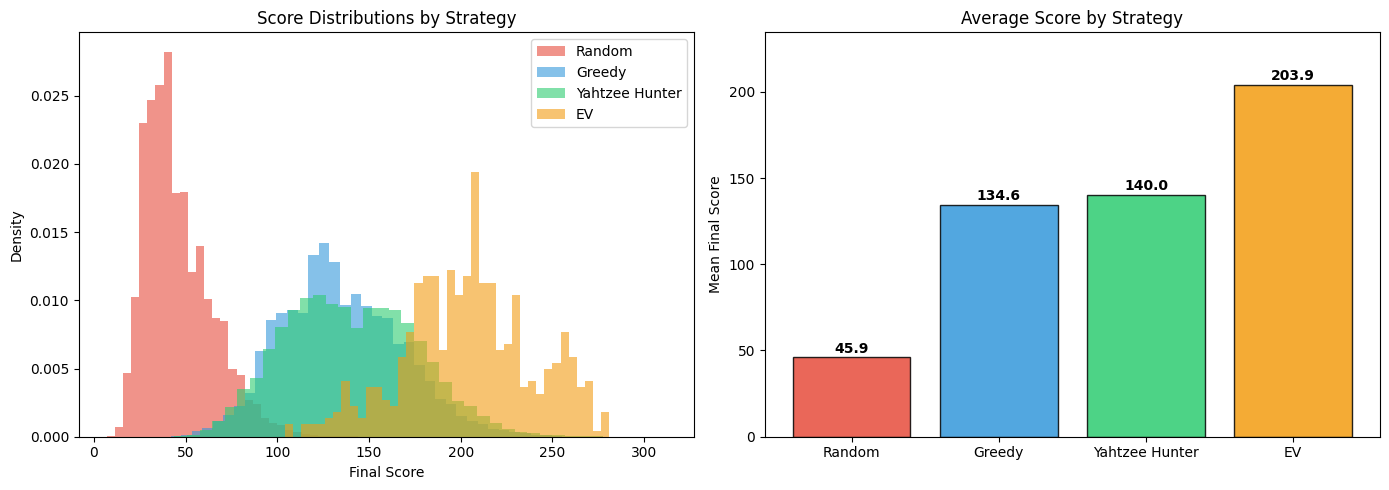

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distributions
ax = axes[0]
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
for (name, scores), color in zip(results.items(), colors):
    ax.hist(scores, bins=40, alpha=0.6, label=name, color=color, density=True)
ax.set_xlabel("Final Score")
ax.set_ylabel("Density")
ax.set_title("Score Distributions by Strategy")
ax.legend()

# Mean comparison bar chart
ax2 = axes[1]
names = list(results.keys())
means = [np.mean(s) for s in results.values()]
bars = ax2.bar(names, means, color=colors, edgecolor="black", alpha=0.85)
ax2.set_ylabel("Mean Final Score")
ax2.set_title("Average Score by Strategy")
for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylim(0, max(means) * 1.15)

plt.tight_layout()
plt.show()

## Single Game Trace
Watch one EV game decision-by-decision. `[d]` = kept die, ` d ` = re-rolled.

In [ ]:
def play_game_verbose(strategy, top_n=4):
    scorecard = {c: None for c in CATEGORIES}
    scorecard["yahtzee_bonus"] = 0
    is_ev = (strategy == strategy_ev)

    for turn in range(1, 14):
        print(f"\n── Turn {turn:2d}  (running total: {total_score(scorecard)}) {'─'*30}")
        dice = roll()
        chosen_category = None

        for roll_num in range(1, 4):
            remaining_rolls = 3 - roll_num

            # Joker check: bonus Yahtzee when box = 50
            if joker_active(dice, scorecard):
                valid_cats = joker_categories(dice, scorecard)
                upper_prog = _upper_progress(scorecard)
                arr = np.array(dice, dtype=np.uint8).reshape(1, 5)
                cat_scores = score_batch(arr, valid_cats, upper_prog,
                                         return_max=False, yahtzee_box=50)[0]
                chosen_category = valid_cats[int(cat_scores.argmax())]
                pts = score_dice_joker(dice, chosen_category)
                scorecard[chosen_category] = pts
                scorecard["yahtzee_bonus"] += 100
                print(f"  Roll {roll_num}: {'  '.join(str(d) for d in dice)}")
                print(f"  ★ YAHTZEE BONUS! +100 pts  →  Joker score '{chosen_category}' = {pts} pts")
                break

            if is_ev and remaining_rolls > 0:
                candidates = smart_keeps(dice, scorecard)
                ev_scores = sorted(
                    [(expected_score_vec(k, dice, scorecard, remaining_rolls, EV_SAMPLES), k)
                     for k in candidates],
                    reverse=True
                )
                keep_indices = ev_scores[0][1]
                chosen_category = None
            else:
                keep_indices, chosen_category = strategy(dice, roll_num, scorecard)

            dice_str = "  ".join(
                f"[{d}]" if i in keep_indices else f" {d} "
                for i, d in enumerate(dice)
            )

            if chosen_category is not None or roll_num == 3:
                if chosen_category is None:
                    open_cats = open_categories(scorecard)
                    upper_prog = _upper_progress(scorecard)
                    arr = np.array(dice, dtype=np.uint8).reshape(1, 5)
                    cat_scores = score_batch(arr, open_cats, upper_prog, return_max=False)[0]
                    chosen_category = open_cats[int(cat_scores.argmax())]
                pts = score_dice(dice, chosen_category)
                scorecard[chosen_category] = pts
                print(f"  Roll {roll_num}: {dice_str}  →  score '{chosen_category}' = {pts} pts")
                break
            else:
                kept_vals = sorted([dice[i] for i in keep_indices])
                print(f"  Roll {roll_num}: {dice_str}  →  keep {kept_vals or 'nothing'}, re-roll rest")

                if is_ev:
                    print(f"    {'Keep':<25} {'EV':>6}")
                    for rank, (ev, k) in enumerate(ev_scores[:top_n]):
                        vals = sorted([dice[j] for j in k])
                        marker = " ◄" if rank == 0 else ""
                        print(f"    {str(vals or []):<25} {ev:>6.1f}{marker}")

                dice = reroll(dice, keep_indices)

    upper_cats = ["ones","twos","threes","fours","fives","sixes"]
    upper_total = sum(scorecard[c] for c in upper_cats)
    bonus = 35 if upper_total >= 63 else 0
    yb = scorecard["yahtzee_bonus"]

    print(f"\n{'═'*55}")
    print(f"{'Category':<22} {'Score':>6}")
    print(f"{'─'*30}")
    for cat in CATEGORIES:
        flag = " ←" if scorecard[cat] == 0 else ""
        print(f"  {cat:<20} {scorecard[cat]:>6}{flag}")
    print(f"{'─'*30}")
    print(f"  {'Upper section':<20} {upper_total:>6}  ({'bonus!' if bonus else f'needed {63-upper_total} more for bonus'})")
    print(f"  {'Upper bonus':<20} {bonus:>6}")
    if yb > 0:
        print(f"  {'Yahtzee bonus':<20} {yb:>6}  ({yb // 100}× bonus Yahtzee)")
    print(f"  {'TOTAL':<20} {total_score(scorecard):>6}")

play_game_verbose(strategy_ev)

## Validation: Smart Keeps vs Exhaustive (All 32)
Tests whether the smart pruning heuristic meaningfully changes EV strategy quality.
Run with n=200 each. If p > 0.05 and the difference is within the confidence interval, pruning is validated.

In [70]:
from scipy import stats

# strategy_ev_exhaustive is defined in the validation cell above.
# Register it so simulate_parallel_progress can find it.
STRATEGY_MAP["ev_exhaustive"] = strategy_ev_exhaustive

N_VAL = 2000

print("Smart keeps EV (n=200):")
t0 = time.perf_counter()
val_smart = simulate_parallel_progress("ev", N_VAL, games_per_chunk=1)
print(f"Done in {time.perf_counter()-t0:.0f}s\n")

print("Exhaustive EV (n=200):")
t0 = time.perf_counter()
val_exhaustive = simulate_parallel_progress("ev_exhaustive", N_VAL, games_per_chunk=1)
print(f"Done in {time.perf_counter()-t0:.0f}s\n")

t_stat, p_val = stats.ttest_ind(val_smart, val_exhaustive)
mean_diff = np.mean(val_smart) - np.mean(val_exhaustive)
se_diff = np.sqrt(np.var(val_smart, ddof=1)/N_VAL + np.var(val_exhaustive, ddof=1)/N_VAL)
ci = 1.96 * se_diff

print(f"Smart keeps:  mean = {np.mean(val_smart):.1f}  std = {np.std(val_smart):.1f}")
print(f"Exhaustive:   mean = {np.mean(val_exhaustive):.1f}  std = {np.std(val_exhaustive):.1f}")
print(f"Difference:   {mean_diff:+.1f} ± {ci:.1f} pts  (95% CI)")
print(f"p = {p_val:.3f}  →  {'no significant difference ✓' if p_val > 0.05 else 'SIGNIFICANT difference — pruning may be lossy'}")

Smart keeps EV (n=200):


ev:   0%|          | 0/2000 [00:00<?, ?game/s]

KeyboardInterrupt: 